SpatialFusion can only be used on ST data directly without WSI to uncover niches. Because the pre-trained model uses both gene expression and H&E, the niches are 'pathology-informed' even if run on ST only. 

In this tutorial we will show how you can run the SpatialFusion pipeline on an ST experiment without H&E.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [2]:
# Standard library
import logging
import os
import warnings
import pathlib as pl

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import shapely.wkb
import tifffile
import timm
import torch
import cv2
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms
from skimage.color import separate_stains, hed_from_rgb

# Warning filters
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
adata = sc.read_h5ad('data/tutadata_subset.h5ad')

# Step 1: Run scGPT on the cell patches

Here we are running scGPT, as this is the RNA-only pretrained version we provide. We will extend the framework to accommodate other RNA FM in the future. If there is a FM you would like integrated, don't hesitate to open an issue on the Github repository.

In [4]:
PATH_SCGPT_WEIGHTS = pl.Path('/ewsc/yatesjos/Broad_SpatialFoundation/scGPT_model/')
PATH_UNI_WEIGHTS = pl.Path('/ewsc/yatesjos/Broad_SpatialFoundation/UNI/pytorch_model.bin')

In [5]:
import sys
sys.path.append('../../../Broad_SpatialFoundation/')

from sc_foundation_evals import scgpt_forward, data
from sc_foundation_evals.helpers.custom_logging import log

log.setLevel(logging.INFO)

/ewsc/yatesjos/spatialfusion_env/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/ewsc/yatesjos/spatialfusion_env/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/ewsc/yatesjos/spatialfusion_env/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/ewsc/yatesjos/spatialfusion_env/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last release

In [6]:
def run_embed_scGPT(
    dataset_path: str,
    model_dir: str,  # path to the pre-trained model, 3 files are expected: model_weights (best_model.pt), model args (args.json), and model vocab (vocab.json)
    output_dir: str,  # output_dir is the path to which the results should be saved
    n_hvg: int,
    gene_col: str = "index",  # in which column in adata.obs are gene names stored? if they are in index, the index will be copied to a column with this name
    layer_key: str = "X",  # where the raw counts are stored?
    log_norm: bool = False,  # are the values log_norm already?
    seed: int = 42,
    max_seq_len: int = 1200,  # maximum sequence of the input is controlled by max_seq_len, here I'm using the pretrained default
    batch_size: int = 32,  # batch_size depends on available GPU memory; should be a multiple of 8
    input_bins: int = 51,
    model_run: str = "pretrained",
    num_workers: int = 0,  # if you can use multithreading specify num_workers
) -> None:


    # create the model
    scgpt_model = scgpt_forward.scGPT_instance(
        saved_model_path=model_dir,
        model_run=model_run,
        batch_size=batch_size,
        save_dir=output_dir,
        num_workers=num_workers,
        explicit_save_dir=True,
    )

    # create config
    scgpt_model.create_configs(seed=seed, max_seq_len=max_seq_len, n_bins=input_bins)

    scgpt_model.load_pretrained_model()

    # This is to keep the model running if the amount of genes is small
    input_data = data.InputData(adata_dataset_path=dataset_path)
    vocab_list = scgpt_model.vocab.get_stoi().keys()

    adata = input_data.adata
    genes_in_vocab = adata.var_names.intersection(vocab_list)
    if len(genes_in_vocab) / len(adata.var_names) < 0.5:
        log.warning("Fewer than 50% of genes are found in the model vocab — continuing anyway.")
    
    adata._inplace_subset_var(genes_in_vocab)
    input_data.adata = adata

    input_data.preprocess_data(
        gene_vocab=vocab_list,
        model_type="scGPT",
        gene_col=gene_col,
        data_is_raw=not log_norm,
        counts_layer=layer_key,
        n_bins=input_bins,
        n_hvg=n_hvg,
    )

    scgpt_model.tokenize_data(
        data=input_data, input_layer_key="X_binned", include_zero_genes=False
    )

    scgpt_model.extract_embeddings(data=input_data)

    pd.DataFrame(
        input_data.adata.obsm["X_scGPT"],
        index=input_data.adata.obs["cell_id"] if "cell_id" in input_data.adata.obs.columns else input_data.adata.obs.index
    ).to_parquet(pl.Path(output_dir) / "scGPT.parquet")


In [7]:
# change this to wherever you saved the data 
base_dir = pl.Path('data/')
sample_name = 'SUBSET_Xenium_Ovarian-5k'
adata_path = base_dir / "tutadata_subset.h5ad"

model_dir_GPT = PATH_SCGPT_WEIGHTS

In [ ]:
print(f'Starting for {sample_name}')
run_embed_scGPT(
    dataset_path=str(adata_path),
    model_dir=str(model_dir_GPT),
    output_dir=str(base_dir),  
    n_hvg=1200,
    gene_col="index",
    layer_key="X",
    log_norm=False,
    seed=42,
    max_seq_len=1200,
    batch_size=16,
    input_bins=51,
    model_run="pretrained",
    num_workers=0,
)

# Step 2: Embed using SpatialFusion (RNA)

In [8]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding
from spatialfusion.utils.pkg_ckpt import resolve_pkg_ckpt

In [9]:
output_dir = 'data/'

In [10]:
scgpt_df = pd.read_parquet(pl.Path(output_dir) / 'scGPT.parquet')

In [11]:
ae_model_path = resolve_pkg_ckpt("checkpoint_dir_ae/spatialfusion-ae-uni-scgpt.pt")
### HERE IT'S IMPORT TO POINT TO THE RNA ONLY VARIANT OF SPATIALFUSION
gcn_model_path = resolve_pkg_ckpt("checkpoint_dir_gcn/spatialfusion-rna-gcn-uni-scgpt.pt")

In [13]:
# can run this for several samples at a time
# the second input is None here in H&E only
ae_inputs_by_sample = {
    'crop': AEInputs(adata=adata, z_he=None, z_rna=scgpt_df),
}

# this uses the average version
emb_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    device='cuda',
    combine_mode="z2", # IMPORTANT! z2= H&E only mode
    spatial_key='spatial',
    celltype_key='major_celltype',
    ae_model_path=ae_model_path,
    gcn_model_path=gcn_model_path,
    save_ae_dir=None,  # optional
)

Running GCN inference: 100%|██████████████████████| 1/1 [00:04<00:00,  4.71s/it]


In [14]:
emb_df.columns = emb_df.columns.astype(str)

adata.obsm['SpatialFusion'] = emb_df.set_index('cell_id').loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]

## Now we cluster to obtain niches

In [15]:
sc.pp.neighbors(adata, use_rep='SpatialFusion')

In [25]:
sc.tl.leiden(adata, resolution=0.07, flavor="igraph", n_iterations=2)
# Display number of clusters
adata.obs.leiden.value_counts()

leiden
4    14794
3    12379
2    11163
1     6903
0     1452
Name: count, dtype: int64

In [26]:
adata.obs['X_coord'] = adata.obsm['spatial'][:,0]
adata.obs['Y_coord'] = adata.obsm['spatial'][:,1]

We can now visualize the niches in space

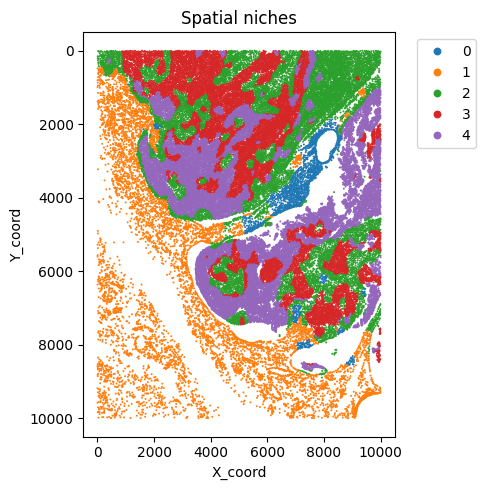

In [27]:
adata.obs['leiden'] = adata.obs['leiden'].astype(str).astype('category')
plt.style.use('default')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# --- Plot 1: Spatial niches ---
sns.scatterplot(
    ax=ax,
    data=adata.obs,
    x='X_coord', y='Y_coord',
    hue='leiden',
    palette='tab10',
    s=2,
    linewidth=0
)
ax.invert_yaxis()
ax.set_title("Spatial niches")
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    scatterpoints=1,
    markerscale=4
)

plt.tight_layout()